# Lista 01 de Visão Computacional
Beatriz Rodrigues Cavalcante - 22210505

Hugo Coêlho da Silva - 22111533

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [31]:
def show_images(*images: np.ndarray, titles: list[str] | None = None, columns: int = 2, scale: int = 5) -> None:
    num_images = len(images)
    
    if titles is None:
        titles = [f'Image {i+1}' for i in range(num_images)]
    
    rows = (num_images + columns - 1) // columns 

    fig, axes = plt.subplots(rows, columns, figsize=(scale * columns, scale * rows))
    axes = np.array(axes).reshape(rows, columns)

    for ax, img, title in zip(axes.flat, images, titles):
        ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
        ax.set_title(title)

    for i in range(num_images, rows * columns):
        fig.delaxes(axes.flat[i])

    plt.tight_layout()

def show_image(image: np.ndarray, title: str = None, dpi: int = 100) -> None:
    if len(image.shape) == 2:
        height, width = image.shape
    else:
        height, width, _ = image.shape
    
    figsize = (width / dpi, height / dpi)
    
    plt.figure(figsize=figsize, dpi=dpi)
    plt.imshow(image, cmap='gray' if len(image.shape) == 2 else None)
    plt.title(title if title else "")

    plt.tight_layout()

## Questão 1
Nesta questão, foram implementadas funções para **leitura, salvamento e filtragem de imagens PPM (formato P6)**.

- `read_ppm(file_path)`: lê um arquivo `.ppm`, valida o tipo `P6`, extrai metadados (`width`, `height`, `max_val`) e retorna os pixels em um array `numpy`.
- `save_ppm(ppm_image, filename, foldername)`: salva uma imagem PPM no diretório de saída, garantindo que os valores dos pixels estejam no intervalo `[0, 255]`.
- `filter_channel(img, kernel, kernel_size, normalize)`: aplica convolução manual em **um canal** da imagem, com preenchimento por zeros (padding).
- `apply_filter(img, kernel, kernel_size, normalize)`: aplica o filtro em cada canal RGB separadamente e recompõe a imagem final.

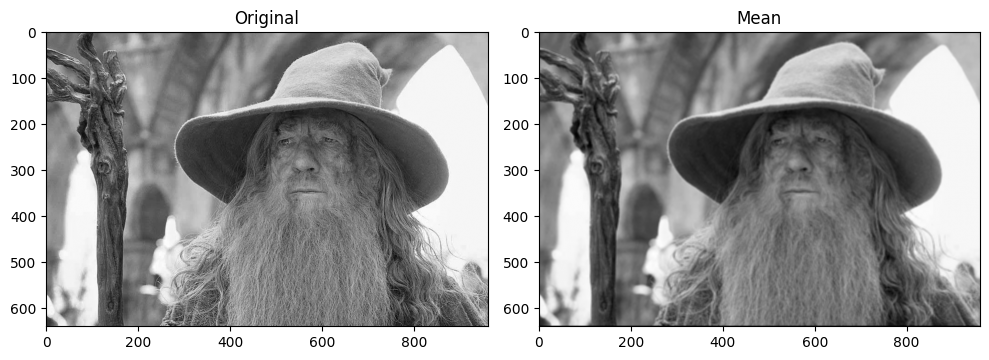

In [32]:
def read_ppm(file_path: str):
    try:
        with open(file_path, 'rb') as f:
            ppm_type = f.readline().strip()
            if ppm_type not in [b'P5', b'P6']:
                raise ValueError("Invalid PPM format. Only P5 and P6 are supported.")

            def token_stream():
                for line in f:
                    line = line.split(b"#", 1)[0].strip()
                    if not line:
                        continue
                    for token in line.split():
                        yield token

            tokens = token_stream()
            width = int(next(tokens))
            height = int(next(tokens))
            max_val = int(next(tokens))
            
            data = np.frombuffer(f.read(), dtype=np.uint8)

            if ppm_type == b'P5':
                pixels = data.reshape((height, width))
            else:
                pixels = data.reshape((height, width, 3))
           
            return {
                "type": ppm_type.decode(),
                "width": width,
                "height": height,
                "max_val": max_val,
                "pixels": pixels,
            }
    except FileNotFoundError:
        print(f'Error: file {file_path} not found.')

def save_ppm(ppm_image, filename: str, foldername:str='./output'):
    folder = Path(foldername)
    folder.mkdir(exist_ok=True, parents=True)
    filepath = folder / Path(filename)

    pixels = np.clip(ppm_image["pixels"], 0, 255).astype(np.uint8)
    img_type = "P5" if len(pixels.shape) == 2 else "P6"

    with open(filepath, 'wb') as ppm:
        ppm.write(f"{img_type}\n".encode('ascii'))
        ppm.write(f"{ppm_image['width']} {ppm_image['height']}\n".encode('ascii'))
        ppm.write(f"{ppm_image['max_val']}\n".encode('ascii'))
        ppm.write(pixels.tobytes())

def filter_channel(img, kernel: np.ndarray, kernel_size: int, normalize: bool = False):
    output = np.zeros(img.shape, dtype=np.float64)
    kernel = np.flip(kernel, axis=(0,1))
    pad_size = kernel_size // 2

    padded_img = np.pad(img.astype(np.float64), pad_size, mode='constant')
    height, width = padded_img.shape

    for i in range(pad_size, height - pad_size):
        for j in range(pad_size, width - pad_size):
            chunk = padded_img[i - pad_size:i + pad_size + 1, j - pad_size:j + pad_size + 1]
            output[i - pad_size, j - pad_size] = np.sum(chunk * kernel)

    if normalize:
        output = (output - np.min(output)) / (np.max(output) - np.min(output)) * 255
    else:
        output = np.clip(output, 0, 255)
    
    return output.astype(np.uint8)

def apply_filter(img, kernel: np.ndarray, kernel_size: int, normalize: bool = False):
    if len(img.shape) == 2:
        return filter_channel(img, kernel, kernel_size, normalize)
    else:
        filtered_channels = []
        for c in range(3):
            filtered_channels.append(filter_channel(img[:, :, c], kernel, kernel_size, normalize))
        return np.stack(filtered_channels, axis=-1)

img_path = 'output/gray-gandalf.ppm'
img = read_ppm(img_path)
n = 5
kernel = mean_kernel = 1 / n**2 * np.ones((n, n), dtype=np.float64)

if img is not None:
    filtered = apply_filter(img["pixels"], kernel, n, True)
    show_images(img["pixels"], filtered, titles=["Original", "Mean"])
    filtered_ppm = {**img, "pixels": filtered}
    output_name = f"{Path(img_path).stem}_mean-filter{Path(img_path).suffix}"
    save_ppm(filtered_ppm, output_name)

## Questão 2

Nesta questão, foi implementado uma função para gerar um kernel Gaussiano normalizado, que será usado em filtros de suavização de imagem.

A função `gaussian_kernel(k, sigma)`:
- recebe o tamanho do kernel `k` (obrigatoriamente ímpar);
- recebe o desvio padrão `sigma`, que controla o espalhamento da Gaussiana;

Se `k` for par, a função lança uma exceção

In [33]:
def gaussian_kernel(k=3, sigma=5) -> np.ndarray:
    if k % 2 == 0:
        raise Exception('k must be an odd number')
    ax = np.linspace(-(k - 1) / 2.0, (k - 1) / 2.0, k)
    gauss = np.exp(-0.5 * np.square(ax) / np.square(sigma))
    kernel = np.outer(gauss, gauss)
    return kernel / np.sum(kernel)

## Questão 3
Nesta questão, foi utilizado as funções implementadas nas questões anteriores para aplicar 9 combinações de kernels para filtrar a imagem.

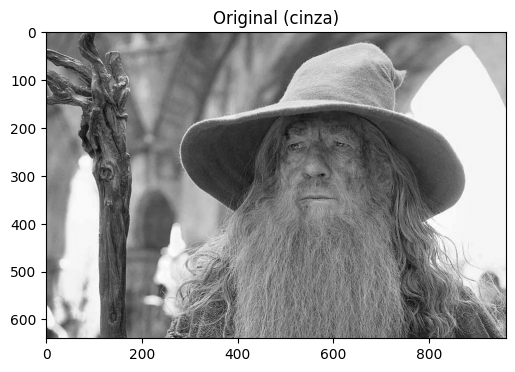

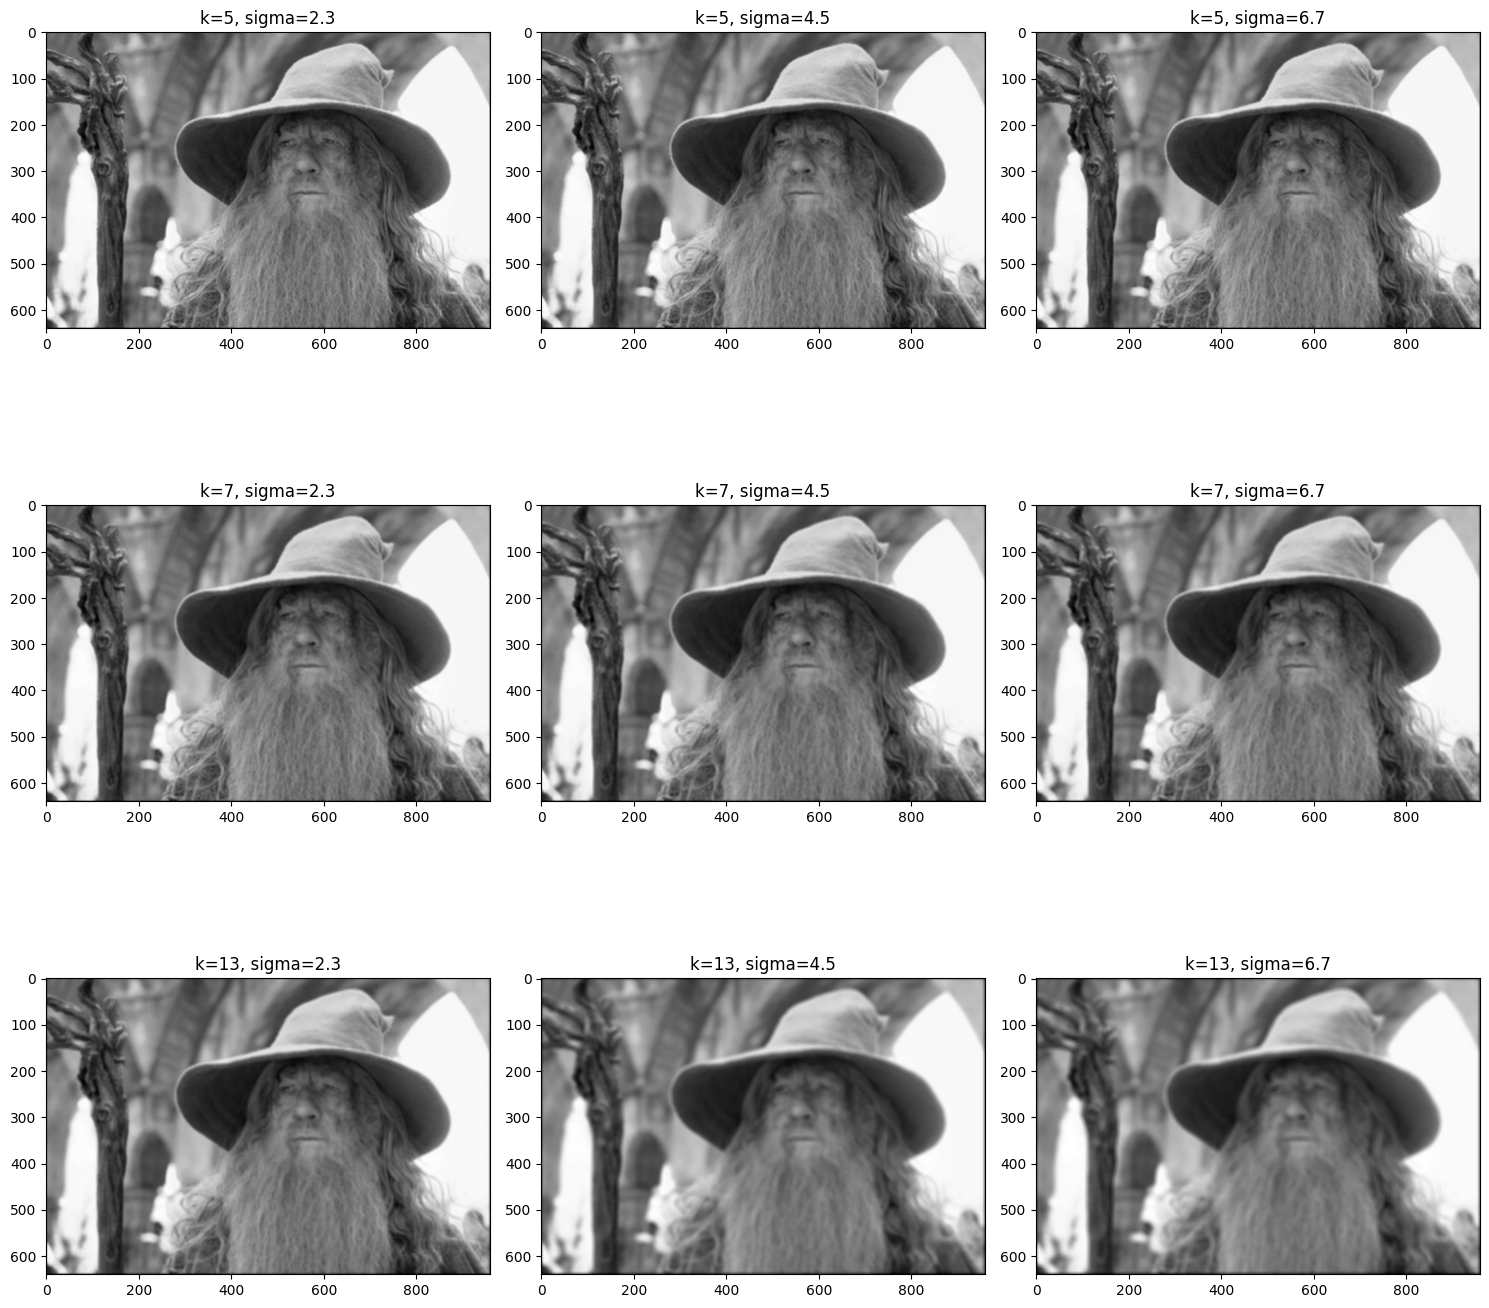

In [37]:
imgPPM = read_ppm('output/gray-gandalf.ppm')
base = imgPPM['pixels']

sizes = [5, 7, 13]
sigmas = [2.3, 4.5, 6.7]

show_images(base, titles=["Original (cinza)"])

images = []
titles = []

for k in sizes:
    for sigma in sigmas:
        kernel = gaussian_kernel(k=k, sigma=sigma)
        imgFiltered = filter_channel(base, kernel, k)
        images.append(imgFiltered)
        titles.append(f'k={k}, sigma={sigma}')

show_images(*images, titles=titles, columns=3)

# Questão 4
Nessa questão, 

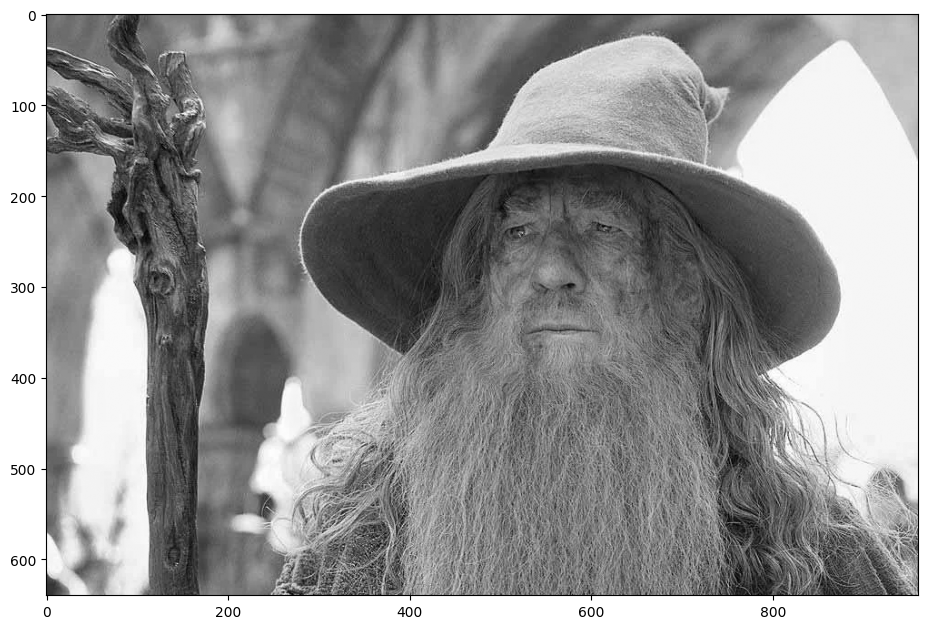

In [36]:
imgPPM = read_ppm(file_path='output/gray-gandalf.ppm')
base = imgPPM['pixels']

show_image(base)